# CIFAR-10 Image Classification with CNN

Convolutional Neural Network for classifying CIFAR-10 images into 10 categories.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics import Accuracy
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## Load Data

CIFAR-10: 60,000 32×32 color images in 10 classes.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

In [3]:
train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

In [4]:
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 50000
Test samples: 10000


In [5]:
!du -sh ./data

341M	./data


In [6]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Model Architecture

CNN with:
- 2 convolutional blocks (Conv2d → ELU → MaxPool2d)
- Feature extractor reduces 32×32 to 8×8
- Fully connected classifier for 10 classes

In [7]:
class CifarClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )

        self.classifier = nn.Linear(4096, num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [8]:
model = CifarClassifier(10)

## Training

Training for 10 epochs with Adam optimizer and CrossEntropyLoss.

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(device)

cuda


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
num_epochs = 20

for epoch in range(1, num_epochs+1):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step() 
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch: {epoch}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch: 1/20, Loss: 1.3379
Epoch: 2/20, Loss: 1.0319
Epoch: 3/20, Loss: 0.9361
Epoch: 4/20, Loss: 0.8648
Epoch: 5/20, Loss: 0.8106
Epoch: 6/20, Loss: 0.7630
Epoch: 7/20, Loss: 0.7224
Epoch: 8/20, Loss: 0.6834
Epoch: 9/20, Loss: 0.6460
Epoch: 10/20, Loss: 0.6159
Epoch: 11/20, Loss: 0.5854
Epoch: 12/20, Loss: 0.5619
Epoch: 13/20, Loss: 0.5360
Epoch: 14/20, Loss: 0.5128
Epoch: 15/20, Loss: 0.4914
Epoch: 16/20, Loss: 0.4670
Epoch: 17/20, Loss: 0.4477
Epoch: 18/20, Loss: 0.4301
Epoch: 19/20, Loss: 0.4146
Epoch: 20/20, Loss: 0.4022


## Evaluation

Test accuracy on 10,000 held-out images.

In [12]:
acc = Accuracy(task='multiclass', num_classes=10)
acc.to(device)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predictions = model(images)
        acc(predictions, labels)
        
    test_accuracy = acc.compute()
    print(f'Test Accuracy: {test_accuracy:.4f}')

Test Accuracy: 0.6674


## Sample Predictions

Visualizing model predictions vs ground truth labels.

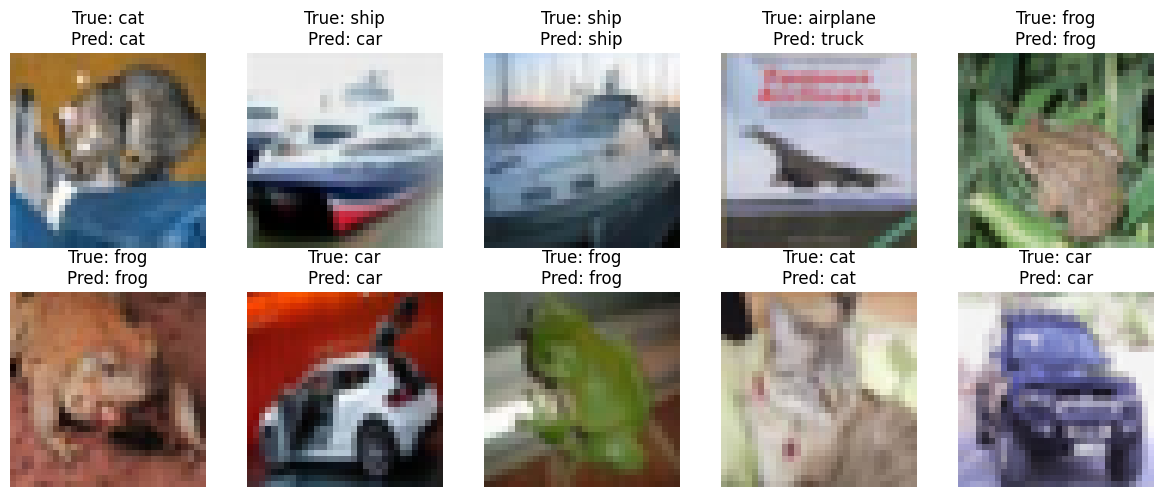

In [13]:
# Show sample predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
classes = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

model.eval()
with torch.no_grad():
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    
    for i, ax in enumerate(axes.flat):
        img = images[i].cpu().permute(1, 2, 0) * 0.5 + 0.5  # Denormalize
        ax.imshow(img)
        ax.set_title(f"True: {classes[labels[i]]}\nPred: {classes[predicted[i]]}")
        ax.axis('off')
plt.tight_layout()
plt.show()